# Homework 09: feature engineering

**Author:** Paritosh Dwivedi

Builds features for the Weekly ETF Risk Monitor from SPY and the VIX volatility index, the same data
profiled in homework 08. Each feature below names the stage 08 finding it comes from, because a
feature invented without evidence is a guess that happens to compile.

The target is realized SPY volatility over the next five sessions — the horizon the project's weekly
review actually uses. All feature logic lives in `src/features.py` so the notebook and any later
stage share one definition.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from src.features import (
                  add_forward_volatility,
                  add_regime_dummies,
                  add_vix_spread,
                  add_vol_ratio,
)

np.random.seed(0)

# Project dataset: SPY daily history joined with the VIX volatility index.
raw = yf.download(['SPY', '^VIX'], start='2015-01-01', interval='1d',
                  auto_adjust=False, progress=False)
frame = pd.concat([raw['Adj Close']['SPY'], raw['Adj Close']['^VIX'], raw['Volume']['SPY']], axis=1)
frame.columns = ['spy_close', 'vix_close', 'spy_volume']
df = frame.dropna().reset_index().rename(columns={'Date': 'date'})
df['daily_return'] = df['spy_close'].pct_change()

print(f'{len(df)} sessions from {df["date"].min().date()} to {df["date"].max().date()}')
df.head()

2926 sessions from 2015-01-02 to 2026-08-21


,date,spy_close,vix_close,spy_volume,daily_return
0,2015-01-02,169.687851,17.790001,121465900.0,NaN
1,2015-01-05,166.623367,19.920000,169632600.0,-0.018060
2,2015-01-06,165.053925,21.120001,209151400.0,-0.009419
3,2015-01-07,167.110703,19.309999,125346700.0,0.012461
4,2015-01-08,170.076096,17.010000,147217800.0,0.017745


## Engineered features

Three features, built by the helpers in `src/features.py`, plus the forward-looking target they are
measured against.

In [3]:
df = add_vol_ratio(df, short=5, long=20)
df = add_vix_spread(df, window=20)
df = add_regime_dummies(df)
df = add_forward_volatility(df, horizon=5)

engineered = ['vol_ratio', 'vix_spread', 'regime_calm', 'regime_normal', 'regime_stressed']
model_frame = df.dropna(subset=[*engineered, 'target_vol_5']).reset_index(drop=True)
print('usable rows:', len(model_frame))
model_frame[['date', 'vol_ratio', 'vix_spread', 'vol_regime', 'target_vol_5']].tail()

usable rows: 2901


,date,vol_ratio,vix_spread,vol_regime,target_vol_5
2896,2026-08-10,0.960278,1.456307,normal,0.075883
2897,2026-08-11,0.414313,1.196072,normal,0.088277
2898,2026-08-12,0.415065,0.493609,calm,0.087361
2899,2026-08-13,0.486555,0.658779,calm,0.065806
2900,2026-08-14,0.482501,0.889801,calm,0.087735


### Rationale for feature 1 — `vol_ratio`

**From stage 08:** volatility clusters and mean-reverts around a stable level, with no trend. So the
useful question is not "how volatile is it" but "is it accelerating or decaying relative to its own
recent baseline".

`vol_ratio` is 5-session realized volatility over 20-session realized volatility. Above one means
turbulence is building faster than the slow window has absorbed; below one means it is fading. It is
scale free, so it stays comparable between a calm 2017 and a violent 2020, which neither raw window
does on its own.

### Rationale for feature 2 — `vix_spread`

**From stage 08:** VIX tracks realized volatility closely, but the scatter fans out at high VIX —
when implied volatility is high, realized outcomes vary widely.

`vix_spread` is VIX minus trailing realized volatility, both in percentage points. It isolates the
part of implied volatility that is *not* just a restatement of what already happened: the market's
forward view. A wide positive spread says option markets expect more turbulence than has been
delivered. This is the one feature here that carries genuinely forward-looking information, since VIX
is derived from option prices rather than past returns.

### Rationale for feature 3 — `regime_*` (categorical encoding)

**From stage 08:** cutting VIX into calm, normal, and stressed bands gave a heavily imbalanced split,
and the VIX-to-realized-volatility relationship visibly curves rather than running straight.

That curvature is the argument for a categorical encoding: a linear model reads a continuous VIX as
"each point of VIX adds a fixed amount of risk", which the scatter contradicts. Banding lets the
model fit a different level per regime.

**Why one-hot over the alternatives.** Label encoding would number the bands 0, 1, 2 and assert that
calm-to-normal is the same distance as normal-to-stressed — the data says it is not. Frequency
encoding would map each band to how often it occurred, conflating rarity with severity, which is
exactly the wrong signal for a risk monitor. One-hot makes no ordering or spacing claim at all, and
with only three bands the extra columns cost nothing.

## Correlation check against the target

In [4]:
checks = engineered + ['vol_20']
corr = model_frame[checks + ['target_vol_5']].corr()['target_vol_5'].drop('target_vol_5')
display(corr.sort_values(ascending=False).round(3).to_frame('correlation with next-5-session vol'))

,correlation with next-5-session vol
vol_20,0.573
regime_stressed,0.501
vol_ratio,0.173
regime_normal,0.007
vix_spread,-0.111
regime_calm,-0.363


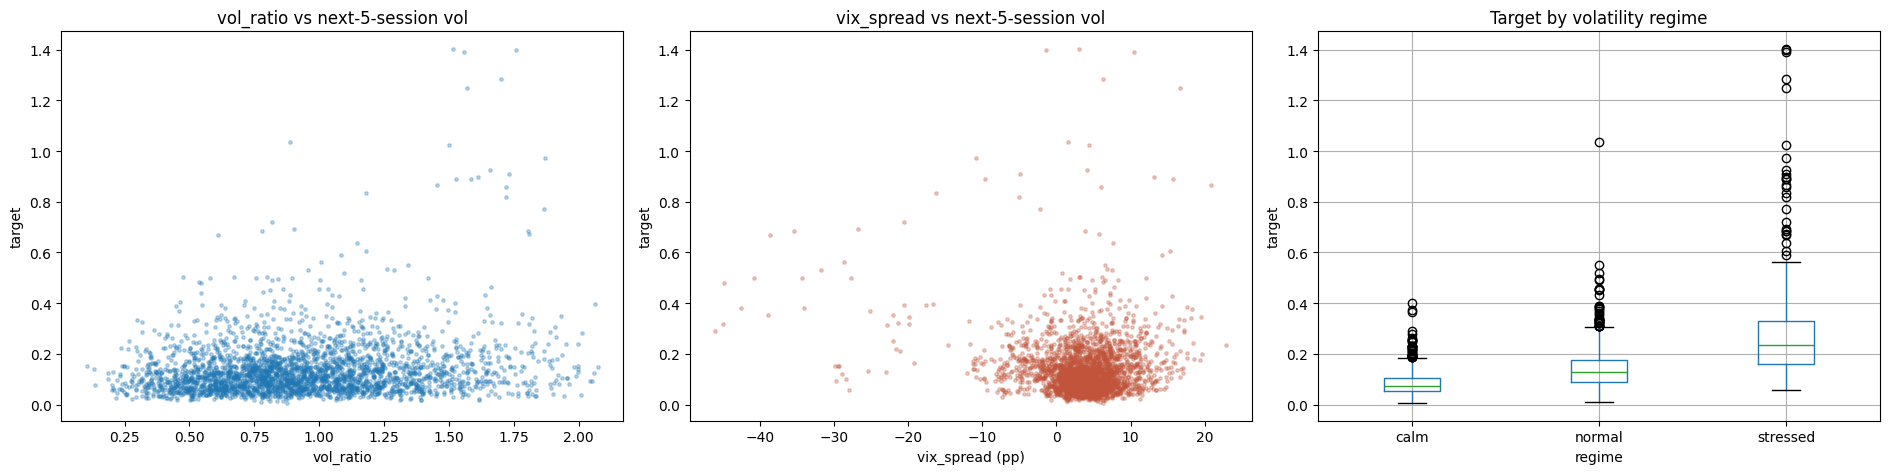

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].scatter(model_frame['vol_ratio'], model_frame['target_vol_5'], s=6, alpha=0.3)
axes[0].set(title='vol_ratio vs next-5-session vol', xlabel='vol_ratio', ylabel='target')
axes[1].scatter(model_frame['vix_spread'], model_frame['target_vol_5'], s=6, alpha=0.3,
                color='#c1543a')
axes[1].set(title='vix_spread vs next-5-session vol', xlabel='vix_spread (pp)', ylabel='target')
model_frame.boxplot(column='target_vol_5', by='vol_regime', ax=axes[2])
axes[2].set(title='Target by volatility regime', xlabel='regime', ylabel='target')
plt.suptitle('')
plt.tight_layout()
plt.show()

**What this tells me.** `regime_stressed` and `vol_ratio` both correlate positively with next-week
volatility, and the boxplot shows the target's whole distribution shifting upward across the three
bands rather than only its mean — which is what makes the banding worth having.

`vix_spread` correlates *negatively*, and that is the interesting result. A wide positive spread
means implied volatility already sits well above what has been realized, and those periods tend to be
followed by calmer weeks than the VIX level alone would suggest. It is picking up mean reversion in
the volatility risk premium, not a stress signal. Read carelessly it would look like a broken
feature; it is doing something real, just not the obvious thing.

The plain 20-session volatility still correlates most strongly of all, which is the honest headline:
**these features add information around a strong baseline, they do not replace it.** That is the
finding stage 10a has to be evaluated against.